In [1]:
import os, math, random, gc, sys
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torch.serialization
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    cohen_kappa_score, confusion_matrix, classification_report
)

torch.serialization.add_safe_globals([np._core.multiarray.scalar])

In [2]:
DATASET_DIR  = '/kaggle/input/datasets/almiraraisa/aptos-2019-224px-aug-v2'
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP      = torch.cuda.is_available()

CLASS_NAMES  = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
NUM_CLASSES  = len(CLASS_NAMES)
BATCH_SIZE   = 32
NUM_EPOCHS   = 100
SEEDS        = [33, 81, 5]
CKPT_DIR     = '/kaggle/working/'
os.makedirs(CKPT_DIR, exist_ok=True)

T_LR           = 1e-3
T_WEIGHT_DECAY = 1e-4

KD_TEMPERATURE = 10.0
KD_ALPHA       = 0.5
S_LR           = 1e-3
S_WEIGHT_DECAY = 1e-4

ORDINAL_MODE = 'coral'
BETA_FEAT    = 0.5
assert ORDINAL_MODE in ('coral', 'corn')

print(f"Device : {device}")
print(f"AMP    : {USE_AMP}")
print(f"Ordinal: {ORDINAL_MODE.upper()}  |  beta_feat = {BETA_FEAT}")

Device : cuda
AMP    : True
Ordinal: CORAL  |  beta_feat = 0.5


In [3]:
def set_seed(seed=33):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [4]:
def save_resume_ckpt(path, epoch, model, optimizer, scheduler, scaler,
                     history, best_qwk, best_preds, best_labels):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'scaler':    scaler.state_dict() if scaler else {},
                'history': history, 'best_qwk': best_qwk,
                'best_preds': best_preds, 'best_labels': best_labels}, path)


def load_resume_ckpt(path, model, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    if scaler and ckpt.get('scaler'):
        scaler.load_state_dict(ckpt['scaler'])
    print(f"  ↺ Resumed from epoch {ckpt['epoch']+1}  "
          f"(best QWK so far: {ckpt['best_qwk']:.4f})")
    return (ckpt['epoch'] + 1, ckpt['history'],
            ckpt['best_qwk'], ckpt['best_preds'], ckpt['best_labels'])


def save_best_weights(path, epoch, model, qwk):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                'qwk': qwk}, path)

In [5]:
class AptosDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img_col = 'id_code' if 'id_code' in self.df.columns else self.df.columns[0]
        fname   = str(row[img_col])
        fname   = fname if fname.endswith('.png') else fname + '.png'
        img     = Image.open(self.image_dir / fname).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(int(row['diagnosis']), dtype=torch.long)


_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]
train_tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize(_MEAN, _STD)])
val_tfm   = transforms.Compose([transforms.ToTensor(), transforms.Normalize(_MEAN, _STD)])

train_df = pd.read_csv(f'{DATASET_DIR}/train_split.csv')
val_df   = pd.read_csv(f'{DATASET_DIR}/val_split.csv')
test_df  = pd.read_csv(f'{DATASET_DIR}/test_split.csv')
train_df['diagnosis'] = train_df['diagnosis'].astype(int)

class_counts   = train_df['diagnosis'].value_counts().sort_index().values
sample_weights = train_df['diagnosis'].map(lambda x: 1.0 / class_counts[int(x)]).values
sampler = WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.float),
                                len(sample_weights), replacement=True)

train_loader = DataLoader(AptosDataset(train_df, f'{DATASET_DIR}/images', train_tfm),
                          batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(AptosDataset(val_df,   f'{DATASET_DIR}/images', val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(AptosDataset(test_df,  f'{DATASET_DIR}/images', val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

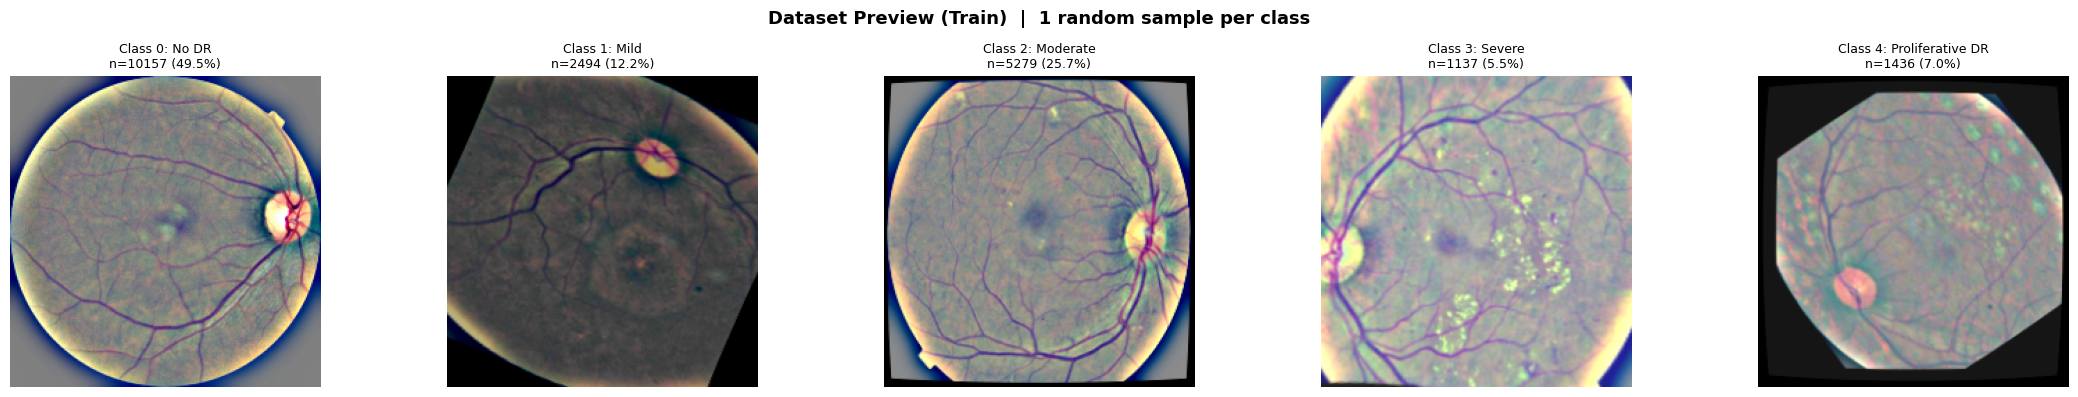


── Dataset Statistics ──────────────────────────────────
  Train: 20503 | Val: 366 | Test: 367
  Class distribution (train):
  [0] No DR               : 10157 ( 49.5%)  ██████████████
  [1] Mild                : 2494 ( 12.2%)  ███
  [2] Moderate            : 5279 ( 25.7%)  ███████
  [3] Severe              : 1137 (  5.5%)  █
  [4] Proliferative DR    : 1436 (  7.0%)  ██


In [6]:
def preview_dataset(df, image_dir, split_name="Train"):
    image_dir = Path(image_dir)
    img_col   = 'id_code' if 'id_code' in df.columns else df.columns[0]
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 4))
    fig.suptitle(f"Dataset Preview ({split_name})  |  1 random sample per class",
                 fontsize=13, fontweight='bold')
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        subset = df[df['diagnosis'] == cls_idx]
        row    = subset.sample(1, random_state=42).iloc[0]
        fname  = str(row[img_col]); fname = fname if fname.endswith('.png') else fname + '.png'
        img    = Image.open(image_dir / fname).convert('RGB')
        axes[cls_idx].imshow(img)
        axes[cls_idx].set_title(
            f"Class {cls_idx}: {cls_name}\nn={len(subset)} ({100*len(subset)/len(df):.1f}%)",
            fontsize=9)
        axes[cls_idx].axis('off')
    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/dataset_preview.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("\n── Dataset Statistics ──────────────────────────────────")
    print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print("  Class distribution (train):")
    for i, name in enumerate(CLASS_NAMES):
        n   = (train_df['diagnosis'] == i).sum()
        bar = '█' * int(30 * n / len(train_df))
        print(f"  [{i}] {name:<20s}: {n:4d} ({100*n/len(train_df):5.1f}%)  {bar}")

preview_dataset(train_df, f'{DATASET_DIR}/images')

In [7]:
class CoralHead(nn.Module):
    """K-1 shared-weight binary ordinal head (Cao et al., 2019)."""
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc   = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1))
    def forward(self, x):
        return self.fc(x) + self.bias                      # (B, K-1)


class CornHead(nn.Module):
    """K-1 independent conditional binary classifiers (Shi, Cao & Raschka 2021)."""
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_features, num_classes - 1)
    def forward(self, x):
        return self.fc(x)                                  # (B, K-1) conditional logits


def make_ordinal_head(in_features, num_classes=NUM_CLASSES):
    return (CoralHead if ORDINAL_MODE == 'coral' else CornHead)(in_features, num_classes)


def coral_loss(logits, labels, num_classes=NUM_CLASSES):
    logits  = logits.float()
    targets = torch.zeros(labels.size(0), num_classes - 1, device=labels.device)
    for k in range(num_classes - 1):
        targets[:, k] = (labels > k).float()
    return F.binary_cross_entropy_with_logits(logits, targets)


def corn_loss(logits, labels, num_classes=NUM_CLASSES):
    """Node k is trained only on samples with y > k-1 (all for k=0); target = (y > k)."""
    logits = logits.float()
    total, n = 0.0, 0.0
    for k in range(num_classes - 1):
        mask = labels > (k - 1)
        if mask.sum() < 1:
            continue
        tgt   = (labels[mask] > k).float()
        total = total + F.binary_cross_entropy_with_logits(
            logits[mask, k], tgt, reduction='sum')
        n += float(mask.sum())
    return total / max(n, 1.0)


def ord_loss(logits, labels):
    return coral_loss(logits, labels) if ORDINAL_MODE == 'coral' else corn_loss(logits, labels)


def ord_cum_probs(logits):
    """P(Y > k) for k = 0..K-2."""
    p = torch.sigmoid(logits.float())
    return p if ORDINAL_MODE == 'coral' else torch.cumprod(p, dim=1)


def ord_predict(logits):
    return (ord_cum_probs(logits) > 0.5).sum(dim=1).long()


def ord_logits_to_probs(logits):
    """Ordinal logits -> normalised K-class probabilities (CORAL and CORN)."""
    B = logits.size(0)
    cum        = ord_cum_probs(logits)                                  # (B, K-1)
    ones       = torch.ones (B, 1, device=logits.device)
    zeros      = torch.zeros(B, 1, device=logits.device)
    cum_padded = torch.cat([ones, cum, zeros], dim=1)                   # (B, K+1)
    probs      = (cum_padded[:, :-1] - cum_padded[:, 1:]).clamp(min=1e-8)
    return probs / probs.sum(dim=1, keepdim=True)


def ord_kd_targets(labels):
    """Binary targets (y > k) and 'active' mask of nodes that see each sample."""
    ks      = torch.arange(NUM_CLASSES - 1, device=labels.device).unsqueeze(0)
    targets = (labels.unsqueeze(1) > ks).float()
    if ORDINAL_MODE == 'coral':
        active = torch.ones_like(targets)
    else:
        active = (labels.unsqueeze(1) > (ks - 1)).float()
    return targets, active

In [8]:
TEACHER_CE_DIM  = 2048   # ResNet-50 pooled feature
TEACHER_ORD_DIM = 1536   # EfficientNet-B3 pooled feature

class DualHeadStudent(nn.Module):
    """
    MobileNetV3-Small backbone
      + nominal (softmax) head       <- logit KD from ResNet-50-CE
      + ordinal (CORAL/CORN) head    <- logit KD from EfficientNet-B3-ordinal
      + 2 feature projectors         <- feature KD (training only; drop at inference)
      + learnable scalar fusion gate.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        backbone = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        in_features = backbone.classifier[-1].in_features            # 1024
        backbone.classifier[-1] = nn.Identity()

        self.backbone     = backbone
        self.nominal_head = nn.Linear(in_features, num_classes)
        self.ordinal_head = make_ordinal_head(in_features, num_classes)
        self.proj_ce      = nn.Linear(in_features, TEACHER_CE_DIM)
        self.proj_ord     = nn.Linear(in_features, TEACHER_ORD_DIM)
        self.fusion_gate  = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        feat = self.backbone(x)
        return self.nominal_head(feat), self.ordinal_head(feat), feat

    def fused_probs(self, nominal_logits, ordinal_logits):
        p_nom = F.softmax(nominal_logits.float(), dim=1)
        p_ord = ord_logits_to_probs(ordinal_logits)
        w     = torch.sigmoid(self.fusion_gate)
        p_final = w * p_nom + (1.0 - w) * p_ord
        return p_final / p_final.sum(dim=1, keepdim=True).clamp(min=1e-8)

In [9]:
def get_resnet50_ce_teacher():
    m    = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def fwd_resnet_ce(model, imgs):                       # logits only (train_teacher)
    return model(imgs)

def fwd_resnet_ce_feat(model, imgs):                  # (logits, pooled feature 2048)
    x = model.maxpool(model.relu(model.bn1(model.conv1(imgs))))
    x = model.layer4(model.layer3(model.layer2(model.layer1(x))))
    feat = model.avgpool(x).flatten(1)
    return model.fc(feat), feat


def get_efficientnet_b3_ord_teacher():
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    in_features      = m.classifier[-1].in_features
    m.classifier[-1] = nn.Identity()
    m.ord_head       = make_ordinal_head(in_features, NUM_CLASSES)
    return m

def fwd_effnet_ord(model, imgs):                      # logits only (train_teacher)
    feat = model.avgpool(model.features(imgs)).flatten(1)
    return model.ord_head(model.classifier(feat))

def fwd_effnet_ord_feat(model, imgs):                 # (logits, pooled feature 1536)
    feat = model.avgpool(model.features(imgs)).flatten(1)
    return model.ord_head(model.classifier(feat)), feat

In [10]:
def _eval_loop(model, loader, pred_fn):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds_all.extend(pred_fn(model, imgs.to(device)).cpu().numpy())
            labels_all.extend(labels.numpy())
    return np.array(preds_all), np.array(labels_all)


def _metrics(p, y):
    return (float(cohen_kappa_score(y, p, weights='quadratic')),
            float(np.mean(y == p)),
            float(np.mean(np.abs(y - p))),
            float(np.sqrt(np.mean((y - p) ** 2))),
            p.tolist(), y.tolist())


def evaluate_val_ce(model, loader):
    p, y = _eval_loop(model, loader, lambda m, x: m(x).argmax(dim=1))
    return _metrics(p, y)


def evaluate_val_ord(model, fwd_fn, loader):
    p, y = _eval_loop(model, loader, lambda m, x: ord_predict(fwd_fn(m, x)))
    return _metrics(p, y)


def dual_predict(model, nominal_logits, ordinal_logits):
    return model.fused_probs(nominal_logits, ordinal_logits).argmax(dim=1)


def _eval_loop_dual(model, loader):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            nom, ordl, _ = model(imgs.to(device))          # feature output ignored
            preds_all.extend(dual_predict(model, nom, ordl).cpu().numpy())
            labels_all.extend(labels.numpy())
    return np.array(preds_all), np.array(labels_all)


def evaluate_val_dual(model, loader):
    p, y = _eval_loop_dual(model, loader)
    return _metrics(p, y)


def evaluate_on_test_dual(model, loader):
    p, y = _eval_loop_dual(model, loader)
    return {'qwk':  float(cohen_kappa_score(y, p, weights='quadratic')),
            'acc':  float(np.mean(y == p)),
            'mae':  float(np.mean(np.abs(y - p))),
            'rmse': float(np.sqrt(np.mean((y - p) ** 2))),
            'preds': p.tolist(), 'labels': y.tolist()}

In [11]:
def train_teacher(model, fwd_fn, loss_fn, eval_fn, name, save_path, seed=33):
    """Only invoked if no pre-trained checkpoint is found."""
    resume_path = save_path.replace('.pth', '_resume.pth')
    set_seed(seed)
    model  = model.to(device)
    opt    = optim.AdamW(model.parameters(), lr=T_LR, weight_decay=T_WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
                   'val_mae': [], 'val_rmse': []}
    best_qwk    = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = load_resume_ckpt(
            resume_path, model, opt, sched, scaler)
        history.setdefault('val_mae',  [None] * len(history['val_qwk']))
        history.setdefault('val_rmse', [None] * len(history['val_qwk']))

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            opt.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    loss = loss_fn(fwd_fn(model, imgs), labels)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else:
                loss = loss_fn(fwd_fn(model, imgs), labels)
                loss.backward(); opt.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        qwk, acc, mae, rmse, vp, vl = eval_fn(model, val_loader)
        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_mae'].append(mae); history['val_rmse'].append(rmse)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | "
              f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk
            best_preds, best_labels = list(vp), list(vl)
            save_best_weights(save_path, epoch + 1, model, best_qwk)
        save_resume_ckpt(resume_path, epoch, model, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    model.load_state_dict(
        torch.load(save_path, map_location=device,
                   weights_only=False)['model_state_dict'])
    model.eval()
    print(f"\n  {name} best val QWK: {best_qwk:.4f}\n")
    return model

In [12]:
T_CE_CKPT  = f'{CKPT_DIR}/hybrid_teacher_resnet50_ce.pth'
T_ORD_CKPT = f'{CKPT_DIR}/hybrid_teacher_efficientnet_{ORDINAL_MODE}.pth'

t_ce  = get_resnet50_ce_teacher().to(device)
t_ord = get_efficientnet_b3_ord_teacher().to(device)

def _load(model, path):
    model.load_state_dict(
        torch.load(path, map_location=device, weights_only=False)['model_state_dict'])

if os.path.exists(T_CE_CKPT):
    _load(t_ce, T_CE_CKPT); print("Loaded ResNet-50-CE teacher.")
else:
    set_seed(33)
    t_ce = train_teacher(model=t_ce, fwd_fn=fwd_resnet_ce,
                         loss_fn=lambda lg, lb: F.cross_entropy(lg, lb),
                         eval_fn=evaluate_val_ce, name="ResNet-50-CE",
                         save_path=T_CE_CKPT, seed=33)
    cleanup_memory()

if os.path.exists(T_ORD_CKPT):
    _load(t_ord, T_ORD_CKPT); print(f"Loaded EfficientNet-B3-{ORDINAL_MODE.upper()} teacher.")
else:
    set_seed(33)
    t_ord = train_teacher(model=t_ord, fwd_fn=fwd_effnet_ord, loss_fn=ord_loss,
                          eval_fn=lambda m, ld: evaluate_val_ord(m, fwd_effnet_ord, ld),
                          name=f"EfficientNet-B3-{ORDINAL_MODE.upper()}",
                          save_path=T_ORD_CKPT, seed=33)
    cleanup_memory()

t_ce.eval(); t_ord.eval()
for p in list(t_ce.parameters()) + list(t_ord.parameters()):
    p.requires_grad_(False)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 224MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 233MB/s]


Loaded ResNet-50-CE teacher.
Loaded EfficientNet-B3-CORAL teacher.


In [13]:
def dp_kd_loss(model, s_nom, s_ord, s_feat,
               t_ce_logits, t_ce_feat, t_ord_logits, t_ord_feat, labels,
               alpha=KD_ALPHA, temperature=KD_TEMPERATURE,
               fusion_weight=0.1, beta=BETA_FEAT):
    """
    total = (1-alpha)*hard + alpha*kd_soft + fusion_weight*fused_nll + beta*feat_loss
      hard      : CE (nominal head) + CORAL/CORN (ordinal head)
      kd_soft   : response-based KD in each teacher's NATIVE space, confidence-weighted
      feat_loss : cosine feature distillation to each teacher, same confidence weights
    """
    T = temperature
    s_nom, s_ord, s_feat = s_nom.float(), s_ord.float(), s_feat.float()
    t_ce_logits, t_ord_logits = t_ce_logits.float(), t_ord_logits.float()
    y_oh = F.one_hot(labels, NUM_CLASSES).float()

    # ---- Branch 1: nominal (categorical) ------------------------------------
    p_ce         = F.softmax(t_ce_logits / T, dim=1)
    ce_nominal   = -(y_oh * (p_ce + 1e-8).log()).sum(dim=1)
    conf_nominal = torch.exp(-ce_nominal).detach()
    kd_nominal   = F.kl_div(F.log_softmax(s_nom / T, dim=1), p_ce,
                            reduction='none').sum(dim=1) * (T ** 2)

    # ---- Branch 2: ordinal (CORAL cumulative / CORN conditional) --------------
    targets, active = ord_kd_targets(labels)
    bce_t = F.binary_cross_entropy_with_logits(t_ord_logits / T, targets, reduction='none')
    ce_ordinal   = (bce_t * active).sum(1) / active.sum(1).clamp(min=1.0)
    conf_ordinal = torch.exp(-ce_ordinal).detach()

    t_soft = torch.sigmoid(t_ord_logits / T).detach()
    s_soft = torch.sigmoid(s_ord / T).clamp(1e-7, 1 - 1e-7)
    kd_ordinal = -(t_soft * s_soft.log() + (1 - t_soft) * (1 - s_soft).log()).sum(dim=1) * (T ** 2)

    denom = conf_nominal + conf_ordinal + 1e-8
    w_nom, w_ord = conf_nominal / denom, conf_ordinal / denom
    kd_soft = (w_nom * kd_nominal + w_ord * kd_ordinal).mean()

    # ---- Feature distillation (cosine), per-teacher, same confidence weights ----
    cos_ce  = F.cosine_similarity(model.proj_ce (s_feat), t_ce_feat.float().detach(),  dim=1)
    cos_ord = F.cosine_similarity(model.proj_ord(s_feat), t_ord_feat.float().detach(), dim=1)
    feat_loss = (w_nom * (1 - cos_ce) + w_ord * (1 - cos_ord)).mean()

    # ---- Hard labels + fusion gate ----------------------------------------------
    hard = 0.5 * F.cross_entropy(s_nom, labels) + 0.5 * ord_loss(s_ord, labels)
    p_final   = model.fused_probs(s_nom, s_ord)
    fused_nll = F.nll_loss(torch.log(p_final.clamp(min=1e-8)), labels)

    return ((1.0 - alpha) * hard + alpha * kd_soft
            + fusion_weight * fused_nll + beta * feat_loss)

In [14]:
def _student_step_loss(student, t_ce_ref, t_ord_ref, imgs, labels):
    s_nom, s_ord, s_feat = student(imgs)
    with torch.no_grad():
        t_ce_logits,  t_ce_feat  = fwd_resnet_ce_feat(t_ce_ref,  imgs)
        t_ord_logits, t_ord_feat = fwd_effnet_ord_feat(t_ord_ref, imgs)
    return dp_kd_loss(student, s_nom, s_ord, s_feat,
                      t_ce_logits, t_ce_feat, t_ord_logits, t_ord_feat, labels)


def train_dual_student(seed, t_ce_model, t_ord_model):
    tag         = f'dpkd_feat_{ORDINAL_MODE}_seed{seed}'
    best_path   = f'{CKPT_DIR}/{tag}_best.pth'
    resume_path = f'{CKPT_DIR}/{tag}_resume.pth'

    set_seed(seed)
    student   = DualHeadStudent(NUM_CLASSES).to(device)
    t_ce_ref  = t_ce_model.to(device).eval()
    t_ord_ref = t_ord_model.to(device).eval()
    for p in list(t_ce_ref.parameters()) + list(t_ord_ref.parameters()):
        p.requires_grad_(False)

    opt    = optim.AdamW(student.parameters(), lr=S_LR, weight_decay=S_WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
                   'val_mae': [], 'val_rmse': [], 'fusion_weight': []}
    best_qwk    = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, student, opt, sched, scaler)
        history.setdefault('val_mae',  [None] * len(history['val_qwk']))
        history.setdefault('val_rmse', [None] * len(history['val_qwk']))
        history.setdefault('fusion_weight', [None] * len(history['val_qwk']))

    for epoch in range(start_epoch, NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            opt.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    loss = _student_step_loss(student, t_ce_ref, t_ord_ref, imgs, labels)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else:
                loss = _student_step_loss(student, t_ce_ref, t_ord_ref, imgs, labels)
                loss.backward(); opt.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        qwk, acc, mae, rmse, vp, vl = evaluate_val_dual(student, val_loader)
        gate_w = float(torch.sigmoid(student.fusion_gate).item())
        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_mae'].append(mae); history['val_rmse'].append(rmse)
        history['fusion_weight'].append(gate_w)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | "
              f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | NominalWeight: {gate_w:.3f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk
            best_preds, best_labels = list(vp), list(vl)
            save_best_weights(best_path, epoch + 1, student, best_qwk)
        save_resume_ckpt(resume_path, epoch, student, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    student.load_state_dict(
        torch.load(best_path, map_location=device, weights_only=False)['model_state_dict'])
    student.eval()
    return {'qwk': best_qwk, 'history': history,
            'preds': best_preds, 'labels': best_labels,
            'seed': seed, 'model': student}

In [15]:
def analyse_results(results_list, scenario_title,
                    loss_label="Loss", test_results_list=None):
    import matplotlib.ticker as mticker

    seeds       = [r['seed'] for r in results_list]
    all_losses  = np.array([r['history']['train_loss'] for r in results_list])
    all_qwks    = np.array([r['history']['val_qwk']    for r in results_list])
    all_accs    = np.array([r['history']['val_acc']    for r in results_list])
    all_maes    = np.array([r['history']['val_mae']    for r in results_list], dtype=float)
    epochs      = np.arange(1, all_losses.shape[1] + 1)
    best_res    = max(results_list, key=lambda x: x['qwk'])
    colors      = plt.cm.tab10.colors

    cms         = [confusion_matrix(r['labels'], r['preds'], labels=list(range(NUM_CLASSES)))
                   for r in results_list]
    cm_avg      = np.mean(cms, axis=0)
    cm_std      = np.std(cms,  axis=0)
    cm_avg_norm = cm_avg / cm_avg.sum(axis=1, keepdims=True)
    cm_best     = confusion_matrix(best_res['labels'], best_res['preds'],
                                   labels=list(range(NUM_CLASSES)))

    seed_accs   = [np.mean(np.array(r['labels']) == np.array(r['preds'])) * 100
                   for r in results_list]
    seed_maes   = [np.mean(np.abs(np.array(r['labels']) - np.array(r['preds'])))
                   for r in results_list]
    mean_acc    = np.mean(seed_accs);  std_acc  = np.std(seed_accs)
    mean_qwk    = np.mean([r['qwk'] for r in results_list])
    std_qwk     = np.std([r['qwk']  for r in results_list])
    mean_mae    = np.mean(seed_maes);  std_mae  = np.std(seed_maes)
    per_cls_acc = cm_avg.diagonal() / cm_avg.sum(axis=1)

    misclass = sorted(
        [(cm_avg[i,j], i, j) for i in range(NUM_CLASSES)
         for j in range(NUM_CLASSES) if i != j and cm_avg[i,j] > 0],
        reverse=True)

    report   = classification_report(best_res['labels'], best_res['preds'],
                                     target_names=CLASS_NAMES, output_dict=True)
    best_acc = np.mean(np.array(best_res['labels']) == np.array(best_res['preds'])) * 100
    safe     = (scenario_title.replace(' ', '_').replace('/', '_')
                               .replace('(', '').replace(')', ''))

    def _ann(ax, cm, fmt='count'):
        thresh = cm.max() / 2
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                v = cm[i, j]
                t = f"{v:.3f}" if fmt == 'norm' else f"{v:.0f}"
                ax.text(j, i, t, ha='center', va='center', fontsize=7.5,
                        color='white' if v > thresh else 'black')

    # ── Dashboard 4×4 ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(24, 20))
    fig.suptitle(f"{scenario_title}\n— Training Analysis Dashboard —",
                 fontsize=16, fontweight='bold', y=0.99)
    gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.42, wspace=0.30)

    for col, (data, color, yl, title, mu, std) in enumerate([
        (seed_accs, '#aec6e8', 'Accuracy (%)', f'Val Accuracy ({len(seeds)} Seeds)',
         mean_acc, std_acc),
        ([r['qwk'] for r in results_list], '#b8d4a8', 'QWK',
         f'Val QWK ({len(seeds)} Seeds)', mean_qwk, std_qwk),
        (seed_maes, '#f4c2c2', 'MAE', f'Val MAE ({len(seeds)} Seeds)',
         mean_mae, std_mae),
    ]):
        ax = fig.add_subplot(gs[0, col])
        bp = ax.boxplot([data], patch_artist=True, widths=0.4,
                        medianprops=dict(color='red', lw=2))
        bp['boxes'][0].set_facecolor(color)
        ax.scatter([1]*len(data), data, color='black', s=40, zorder=5)
        ax.set_xticks([1]); ax.set_xticklabels(['Student'])
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_ylabel(yl); ax.grid(True, axis='y', ls='--', alpha=0.5)
        fmt = f"μ={mu:.2f}%\nσ={std:.2f}%" if col == 0 else f"μ={mu:.4f}\nσ={std:.4f}"
        ax.text(1, mu, fmt, ha='center', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    ax = fig.add_subplot(gs[0, 3])
    ml = all_losses.mean(0); sl = all_losses.std(0)
    ax.plot(epochs, ml, color='blue', lw=2.0, label=loss_label)
    ax.fill_between(epochs, ml-sl, ml+sl, alpha=0.15, color='blue')
    ax.set_title("Training Loss (Averaged)", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ma = all_accs.mean(0)*100; sa = all_accs.std(0)*100
    mq = all_qwks.mean(0);     sq = all_qwks.std(0)
    valid = ~np.isnan(all_maes).all(axis=0)
    mm = np.nanmean(all_maes, axis=0); sm = np.nanstd(all_maes, axis=0)

    for col, (y, sy, ep, color, yl, title) in enumerate([
        (ma, sa, epochs,        '#1f77b4', 'Accuracy (%)', 'Val Accuracy Curves'),
        (mq, sq, epochs,        '#2ca02c', 'QWK',          'Val QWK Curves'),
        (mm[valid], sm[valid], epochs[valid], '#d62728', 'MAE', 'Val MAE Curves'),
    ]):
        ax = fig.add_subplot(gs[1, col])
        ax.plot(ep, y, color=color, lw=2.2, label='Mean')
        ax.fill_between(ep, y-sy, y+sy, alpha=0.25, color=color, label='±1 std')
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel("Epoch"); ax.set_ylabel(yl)
        ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[1, 3])
    ax.plot(epochs, all_qwks.mean(0)/(all_losses.mean(0)+1e-8),
            color='purple', lw=1.8)
    ax.set_title("QWK / Loss Ratio", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Ratio")
    ax.grid(True, ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[2, 0])
    for i, r in enumerate(results_list):
        ax.plot(epochs, [a*100 for a in r['history']['val_acc']],
                color=colors[i], lw=1.5, alpha=0.8, label=f"Seed {r['seed']}")
    ax.plot(epochs, ma, 'k--', lw=2.2, label='Average')
    ax.set_title("Individual Acc Curves", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[2, 1])
    for i, r in enumerate(results_list):
        mr = [m for m in r['history']['val_mae'] if m is not None]
        ax.plot(epochs[:len(mr)], mr, color=colors[i], lw=1.5,
                alpha=0.8, label=f"Seed {r['seed']}")
    ax.plot(epochs[valid], mm[valid], 'k--', lw=2.2, label='Average')
    ax.set_title("Individual MAE Curves", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("MAE")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    for col, (cm, cmap, title, fmt) in enumerate([
        (cm_avg,      'Blues', 'Avg CM (Raw Counts)',  'count'),
        (cm_avg_norm, 'Blues', 'Avg CM (Normalised)', 'norm'),
    ]):
        ax = fig.add_subplot(gs[2, 2+col])
        im = ax.imshow(cm, cmap=cmap, interpolation='nearest',
                       **({'vmin': 0, 'vmax': 1} if fmt == 'norm' else {}))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
        ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(title, fontweight='bold', fontsize=11)
        _ann(ax, cm, fmt)

    ax = fig.add_subplot(gs[3, 0])
    bars = ax.bar(range(NUM_CLASSES), per_cls_acc*100,
                  color='#aec6e8', edgecolor='grey', lw=0.8)
    for bar, val in zip(bars, per_cls_acc):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{val*100:.1f}%", ha='center', va='bottom',
                fontsize=8, fontweight='bold')
    ax.set_title("Per-Class Accuracy (Avg CM)", fontweight='bold', fontsize=11)
    ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[3, 1])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("CM Std Dev", fontweight='bold', fontsize=11)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center',
                    va='center', fontsize=7.5, color='black')

    ax = fig.add_subplot(gs[3, 2])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Best CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontweight='bold', fontsize=11)
    _ann(ax, cm_best)

    ax = fig.add_subplot(gs[3, 3])
    f1s = [report[cls]['f1-score'] for cls in CLASS_NAMES]
    f1b = ax.bar(range(NUM_CLASSES), [f*100 for f in f1s],
                 color='#b8d4a8', edgecolor='grey', lw=0.8)
    for bar, val in zip(f1b, f1s):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{val*100:.1f}%", ha='center', va='bottom',
                fontsize=8, fontweight='bold')
    ax.set_title("Per-Class F1 (Best Seed)", fontweight='bold', fontsize=11)
    ax.set_ylabel("F1 Score (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{safe}_dashboard.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ── Detailed CM figure ────────────────────────────────────────────────────
    fig2 = plt.figure(figsize=(20, 20))
    fig2.suptitle(f"{scenario_title}\n— Detailed Confusion Matrix Analysis —",
                  fontsize=15, fontweight='bold', y=0.99)
    gs2 = gridspec.GridSpec(3, 2, figure=fig2, hspace=0.38, wspace=0.28,
                            height_ratios=[1, 1, 0.48])
    for row, col, cm, cmap, title, fmt in [
        (0, 0, cm_avg,      'Blues',   'Average CM (Raw Counts)',   'count'),
        (0, 1, cm_avg_norm, 'Blues',   'Average CM (Normalised)',   'norm'),
        (1, 0, cm_std,      'Oranges', 'CM Standard Deviation',     'std'),
        (1, 1, cm_best,     'Greens',  f'Best CM (Seed {best_res["seed"]})', 'count'),
    ]:
        ax = fig2.add_subplot(gs2[row, col])
        kw = {'vmin': 0, 'vmax': 1} if fmt == 'norm' else {}
        im = ax.imshow(cm, cmap=cmap, interpolation='nearest', **kw)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
        ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(title, fontweight='bold', fontsize=12)
        if fmt == 'std':
            for i in range(NUM_CLASSES):
                for j in range(NUM_CLASSES):
                    ax.text(j, i, f"{cm[i,j]:.2f}", ha='center',
                            va='center', fontsize=8.5, color='black')
        else:
            _ann(ax, cm, fmt)

    # Summary text panel
    ax_txt = fig2.add_subplot(gs2[2, :])
    ax_txt.axis('off')
    best_mae = np.mean(np.abs(np.array(best_res['labels']) - np.array(best_res['preds'])))
    lines = ["=" * 80,
             f"  PERFORMANCE SUMMARY — {scenario_title}",
             "=" * 80,
             f"  Seeds trained              : {seeds}",
             f"  Val Accuracy  (mean ± std) : {mean_acc:.2f}% ± {std_acc:.2f}%"
             f"  [{min(seed_accs):.2f}% – {max(seed_accs):.2f}%]",
             f"  Val QWK       (mean ± std) : {mean_qwk:.4f} ± {std_qwk:.4f}"
             f"  [{min(r['qwk'] for r in results_list):.4f} – "
             f"{max(r['qwk'] for r in results_list):.4f}]",
             f"  Val MAE       (mean ± std) : {mean_mae:.4f} ± {std_mae:.4f}"
             f"  [{min(seed_maes):.4f} – {max(seed_maes):.4f}]",
             f"  Best seed                  : Seed {best_res['seed']}"
             f"  (QWK={best_res['qwk']:.4f}, Acc={best_acc:.2f}%, MAE={best_mae:.4f})",
             f"  Final train loss (mean)    : "
             f"{all_losses[:,-1].mean():.4f} ± {all_losses[:,-1].std():.4f}",
             f"  Peak QWK epoch  (mean)     : "
             f"{np.mean([np.argmax(r['history']['val_qwk'])+1 for r in results_list]):.1f}",
             ""]
    if test_results_list:
        lines.append("  Test Set Results:")
        for tr in test_results_list:
            lines.append(f"    Seed {tr['seed']}: QWK={tr['qwk']:.4f} | "
                         f"Acc={tr['acc']*100:.2f}% | "
                         f"MAE={tr['mae']:.4f} | RMSE={tr['rmse']:.4f}")
        tq = [r['qwk'] for r in test_results_list]
        ta = [r['acc']*100 for r in test_results_list]
        lines += [f"  Test QWK mean : {np.mean(tq):.4f} ± {np.std(tq):.4f}",
                  f"  Test Acc mean : {np.mean(ta):.2f}% ± {np.std(ta):.2f}%", ""]
    lines += ["  Per-class Performance (best seed):",
              f"  {'Class':<20s}  {'Precision':>9s}  {'Recall':>9s}  "
              f"{'F1-Score':>9s}  {'Support':>7s}",
              "  " + "-" * 60]
    for cls in CLASS_NAMES:
        d = report[cls]
        lines.append(f"  {cls:<20s}  {d['precision']:>9.3f}  {d['recall']:>9.3f}  "
                     f"{d['f1-score']:>9.3f}  {int(d['support']):>7d}")
    lines += ["  " + "-" * 60,
              f"  {'Overall Accuracy':<20s}  {'—':>9s}  {'—':>9s}  "
              f"{report['accuracy']:>9.3f}  {len(best_res['labels']):>7d}",
              f"  {'Macro Avg F1':<20s}  {report['macro avg']['precision']:>9.3f}  "
              f"{report['macro avg']['recall']:>9.3f}  "
              f"{report['macro avg']['f1-score']:>9.3f}",
              f"  {'Weighted Avg F1':<20s}  "
              f"{report['weighted avg']['precision']:>9.3f}  "
              f"{report['weighted avg']['recall']:>9.3f}  "
              f"{report['weighted avg']['f1-score']:>9.3f}",
              "",
              "  Top-5 Most Common Misclassifications (averaged across seeds):"]
    for rank, (cnt, tc, pc) in enumerate(misclass[:5], 1):
        pct = cnt / cm_avg.sum(axis=1)[tc] * 100
        lines.append(f"    {rank}. True={CLASS_NAMES[tc]:<20s} → "
                     f"Predicted={CLASS_NAMES[pc]:<20s}"
                     f"  (avg={cnt:.1f}, {pct:.1f}% of true class)")
    cls_s = sorted(zip(per_cls_acc, CLASS_NAMES), reverse=True)
    lines += ["", "  Class Accuracy Range (averaged CM):",
              f"    Best : {cls_s[0][1]}  ({cls_s[0][0]*100:.1f}%)",
              f"    Worst: {cls_s[-1][1]}  ({cls_s[-1][0]*100:.1f}%)",
              f"    Gap  : {(cls_s[0][0]-cls_s[-1][0])*100:.1f}pp",
              "=" * 80]
    ax_txt.text(0.01, 0.99, '\n'.join(lines), transform=ax_txt.transAxes,
                fontsize=8.2, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f8f9fa',
                          alpha=0.9, edgecolor='#dee2e6'))
    fig2.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{safe}_cm_detail.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('\n'.join(lines))

In [16]:
results_dpkd, trained_dpkd = [], []
for seed in SEEDS:
    print(f"\n  DP-KD logit+feature | ResNet-50-CE + EfficientNet-B3-{ORDINAL_MODE.upper()} "
          f"-> MobileNetV3-Small | Seed {seed}\n")
    res = train_dual_student(seed, t_ce, t_ord)
    results_dpkd.append(res); trained_dpkd.append(res['model'])
    cleanup_memory()

test_results_dpkd = []
for seed, student_model, res in zip(SEEDS, trained_dpkd, results_dpkd):
    tr = evaluate_on_test_dual(student_model, test_loader)
    tr['seed'] = seed; tr['history'] = res['history']
    test_results_dpkd.append(tr)
    print(f"  Test QWK={tr['qwk']:.4f} | Acc={tr['acc']*100:.2f}% | "
          f"RMSE={tr['rmse']:.4f} | MAE={tr['mae']:.4f}")


  DP-KD logit+feature | ResNet-50-CE + EfficientNet-B3-CORAL -> MobileNetV3-Small | Seed 33

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 218MB/s]


  ↺ Resumed from epoch 100  (best QWK so far: 0.9107)

  DP-KD logit+feature | ResNet-50-CE + EfficientNet-B3-CORAL -> MobileNetV3-Small | Seed 81

  ↺ Resumed from epoch 100  (best QWK so far: 0.8943)

  DP-KD logit+feature | ResNet-50-CE + EfficientNet-B3-CORAL -> MobileNetV3-Small | Seed 5

  ↺ Resumed from epoch 86  (best QWK so far: 0.9087)
  Epoch 087 | Loss: 50.9545 | Acc: 82.51% | QWK: 0.8954 | MAE: 0.2240 | RMSE: 0.5774 | NominalWeight: 0.951
  Epoch 088 | Loss: 51.1040 | Acc: 83.06% | QWK: 0.8950 | MAE: 0.2213 | RMSE: 0.5797 | NominalWeight: 0.951
  Epoch 089 | Loss: 50.9120 | Acc: 83.33% | QWK: 0.8953 | MAE: 0.2186 | RMSE: 0.5774 | NominalWeight: 0.951
  Epoch 090 | Loss: 51.2204 | Acc: 82.79% | QWK: 0.8964 | MAE: 0.2213 | RMSE: 0.5750 | NominalWeight: 0.952
  Epoch 091 | Loss: 50.8722 | Acc: 82.79% | QWK: 0.8960 | MAE: 0.2213 | RMSE: 0.5750 | NominalWeight: 0.952
  Epoch 092 | Loss: 50.9496 | Acc: 83.06% | QWK: 0.8966 | MAE: 0.2186 | RMSE: 0.5726 | NominalWeight: 0.952
  Ep

/tmp/ipykernel_58/2079930124.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


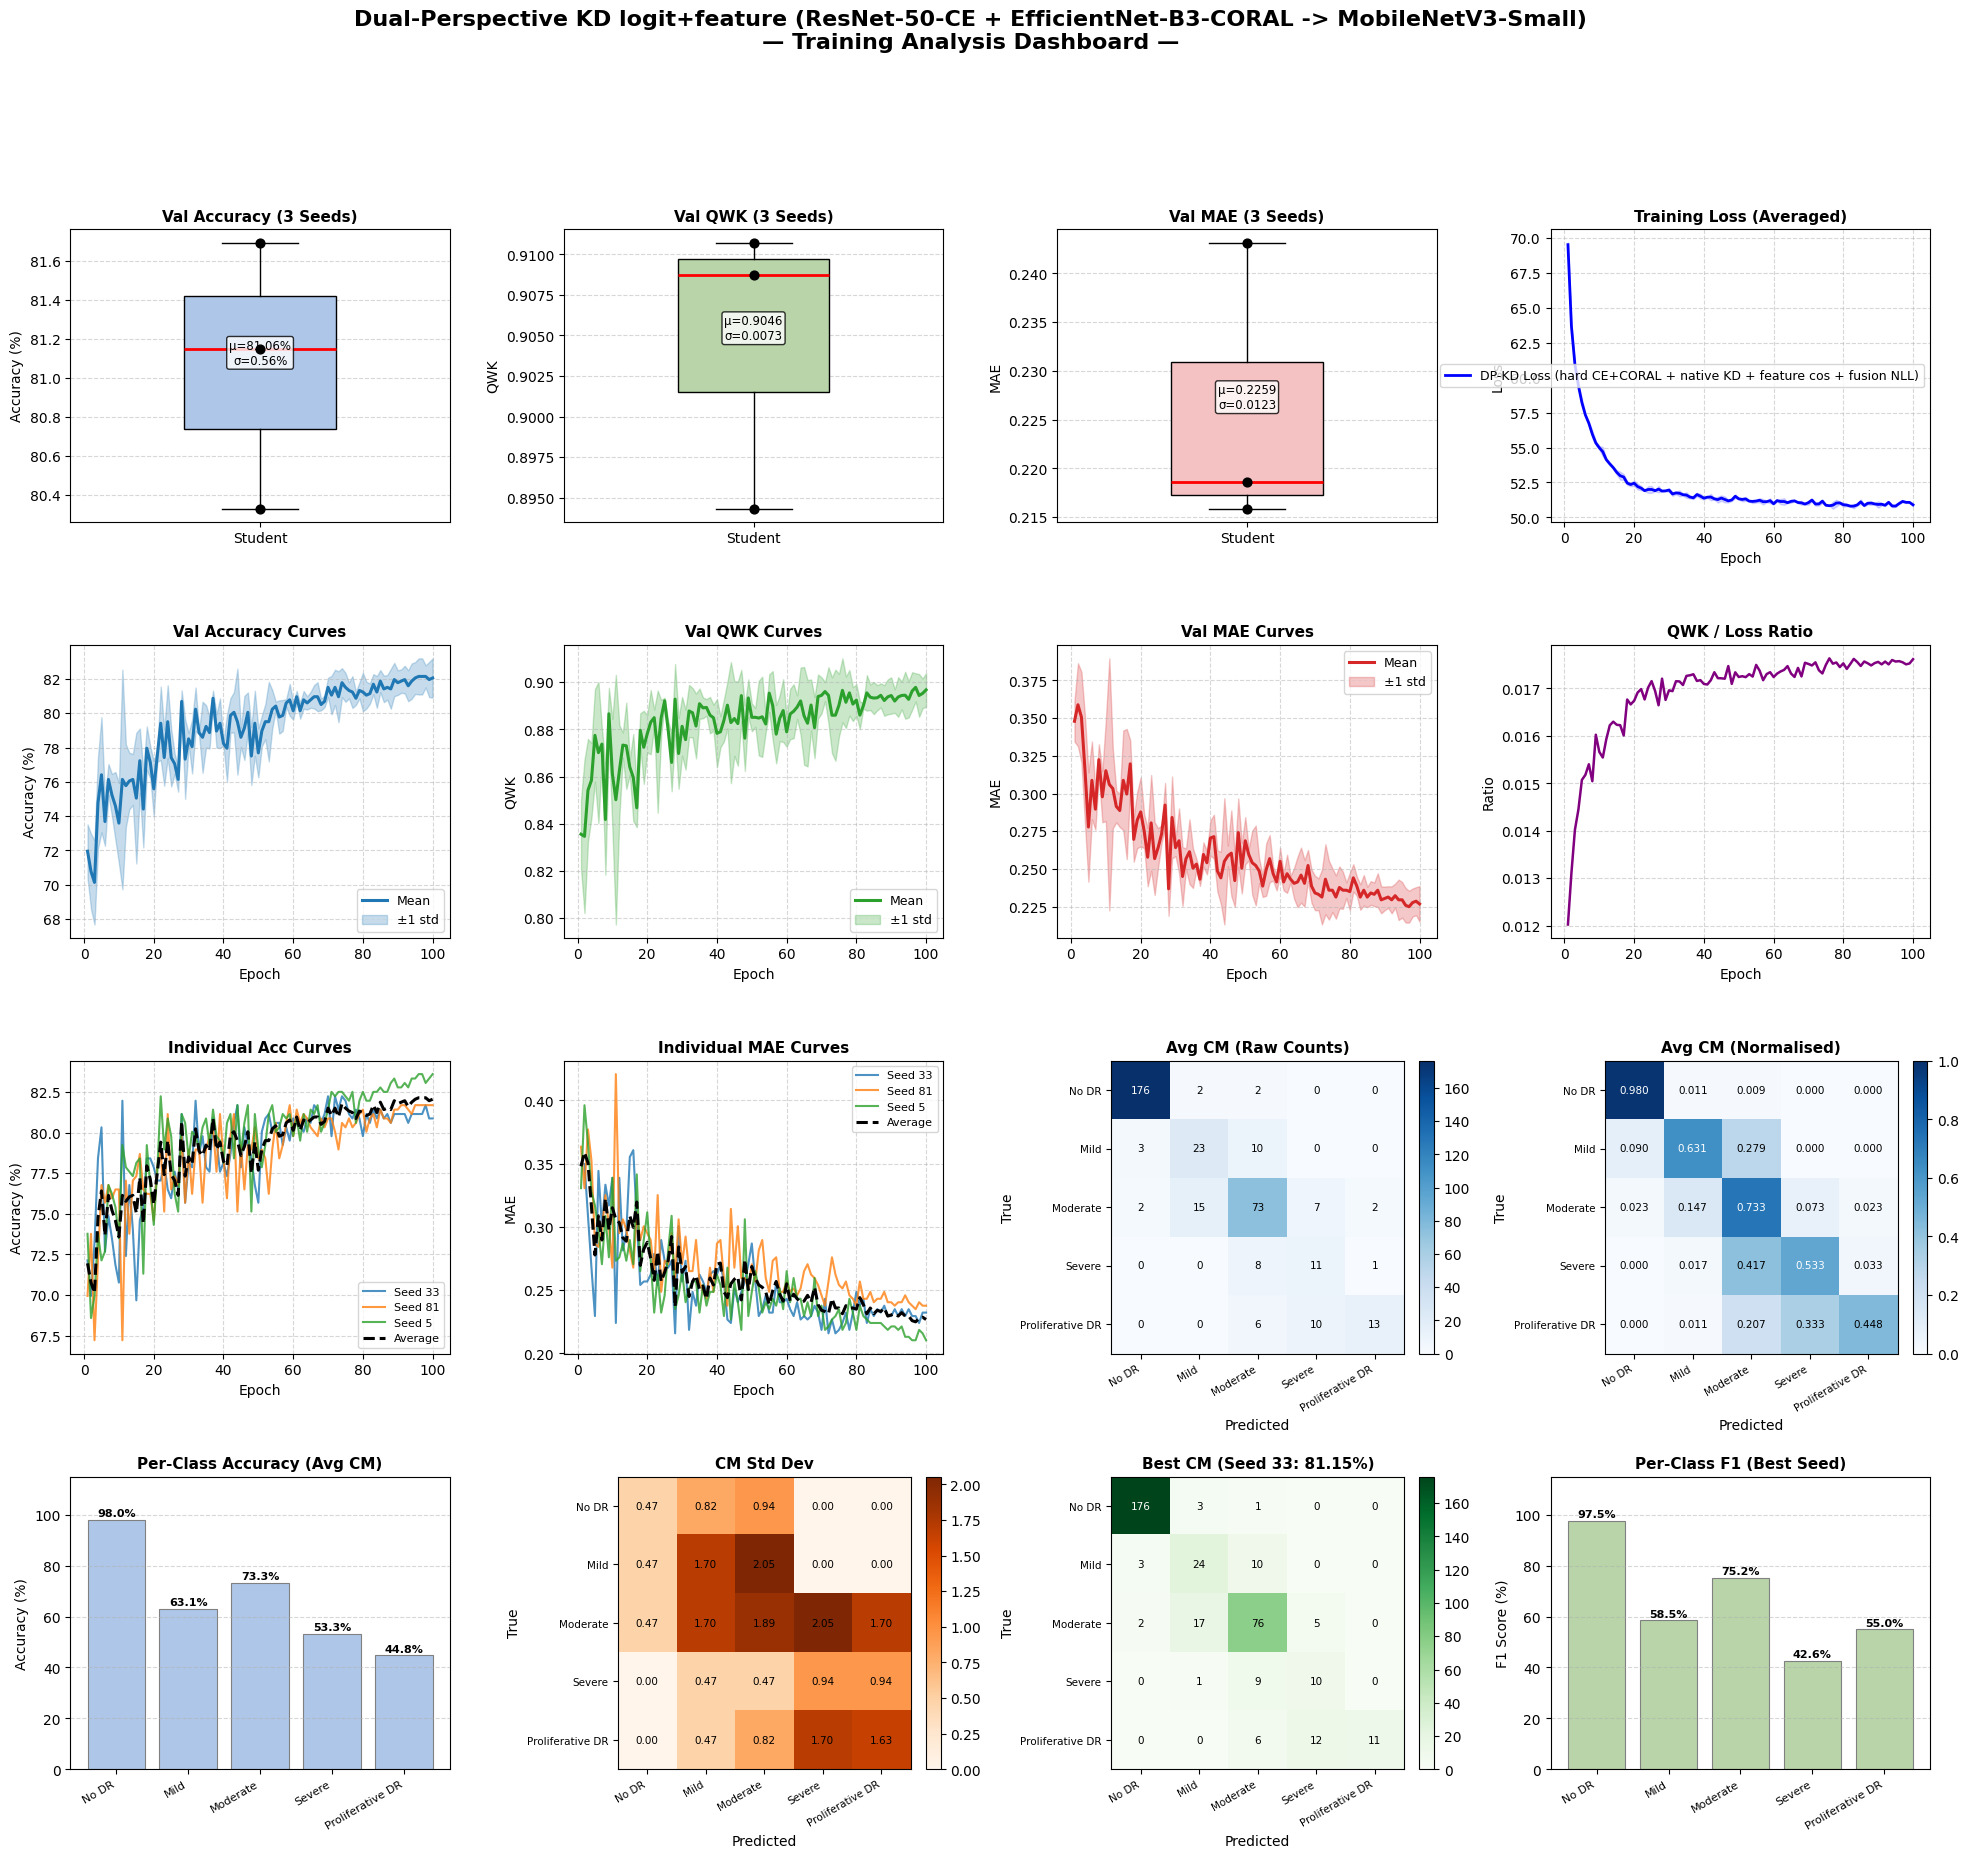

/tmp/ipykernel_58/2079930124.py:295: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout(rect=[0, 0, 1, 0.97])


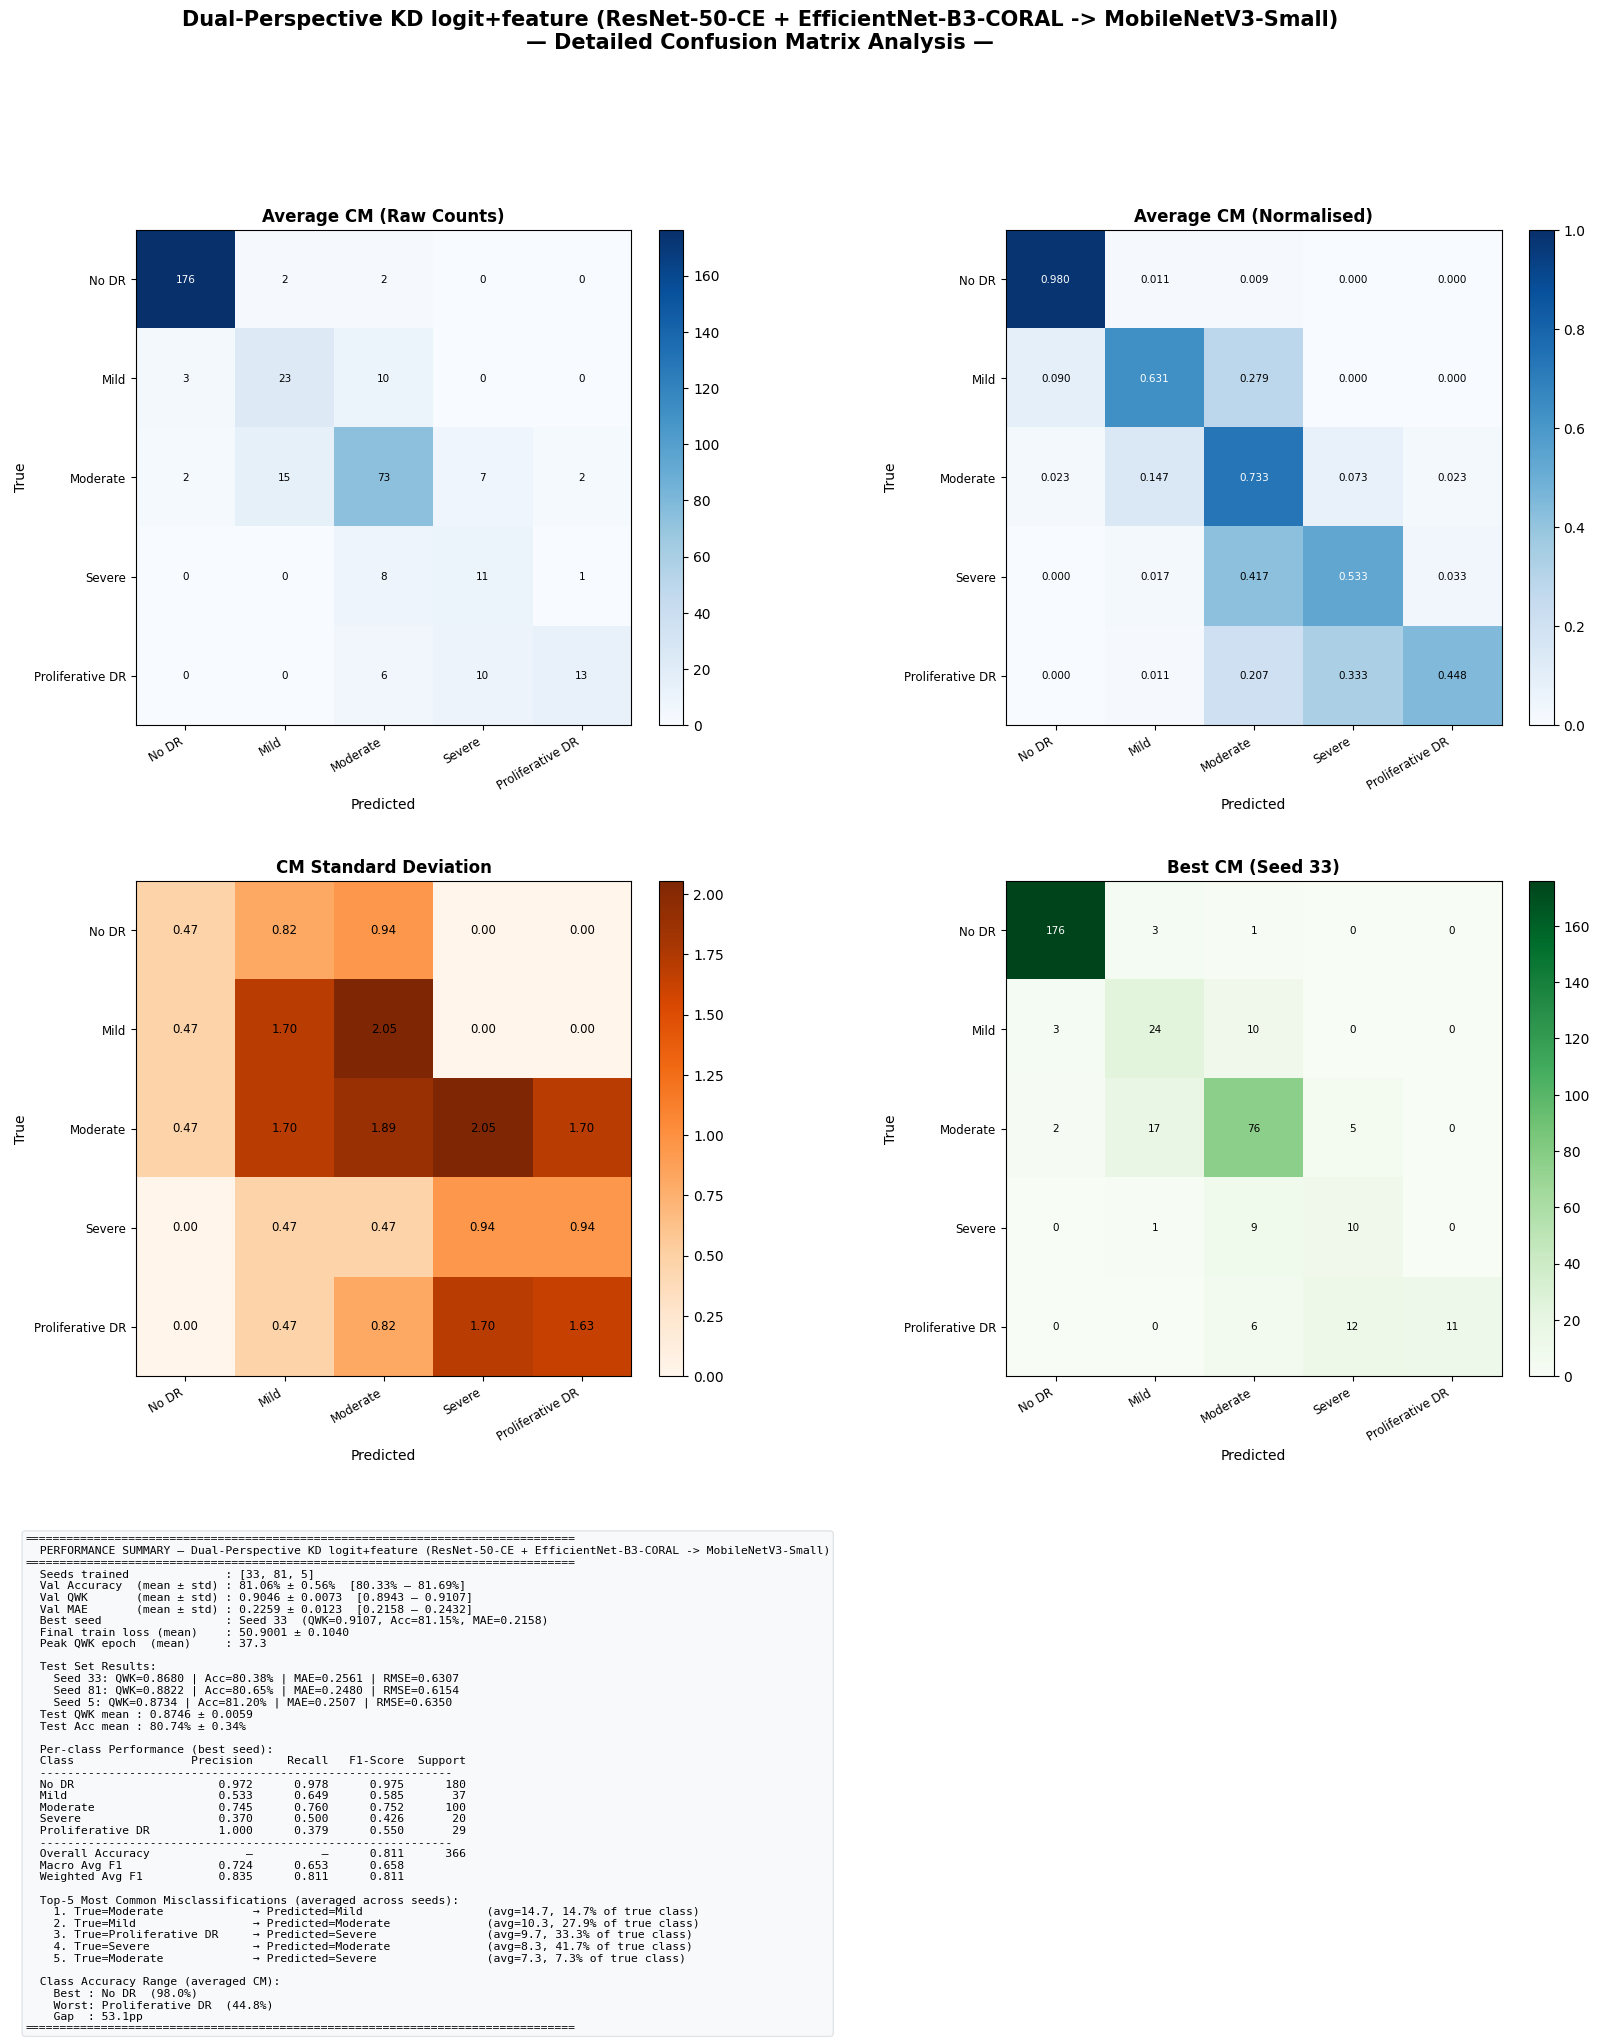

  PERFORMANCE SUMMARY — Dual-Perspective KD logit+feature (ResNet-50-CE + EfficientNet-B3-CORAL -> MobileNetV3-Small)
  Seeds trained              : [33, 81, 5]
  Val Accuracy  (mean ± std) : 81.06% ± 0.56%  [80.33% – 81.69%]
  Val QWK       (mean ± std) : 0.9046 ± 0.0073  [0.8943 – 0.9107]
  Val MAE       (mean ± std) : 0.2259 ± 0.0123  [0.2158 – 0.2432]
  Best seed                  : Seed 33  (QWK=0.9107, Acc=81.15%, MAE=0.2158)
  Final train loss (mean)    : 50.9001 ± 0.1040
  Peak QWK epoch  (mean)     : 37.3

  Test Set Results:
    Seed 33: QWK=0.8680 | Acc=80.38% | MAE=0.2561 | RMSE=0.6307
    Seed 81: QWK=0.8822 | Acc=80.65% | MAE=0.2480 | RMSE=0.6154
    Seed 5: QWK=0.8734 | Acc=81.20% | MAE=0.2507 | RMSE=0.6350
  Test QWK mean : 0.8746 ± 0.0059
  Test Acc mean : 80.74% ± 0.34%

  Per-class Performance (best seed):
  Class                 Precision     Recall   F1-Score  Support
  ------------------------------------------------------------
  No DR                     0.972   

In [17]:
analyse_results(
    results_dpkd,
    f"Dual-Perspective KD logit+feature (ResNet-50-CE + EfficientNet-B3-{ORDINAL_MODE.upper()} -> MobileNetV3-Small)",
    loss_label=f"DP-KD Loss (hard CE+{ORDINAL_MODE.upper()} + native KD + feature cos + fusion NLL)",
    test_results_list=test_results_dpkd,
)